## Produces **Mosquito Predictions** for a specific region using MAMOTH ##

In [1]:
import pandas as pd
import datetime
import math
import numpy as np
import missingno
import json
from statistics import mean
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
import sys

sys.path.insert(0, "../../../Mamoth Modules")
sys.path.insert(0, "../../../Modules")

from preprocessing_utils import *

from Preprocessing_Module import read_data, select_columns, reshape_dataset
from Initializer_Module import initializer
from Neural_Network_Module import Dataset, transformations, FeedforwardNeuralNetModel, train_nn, give_predictions
from Model_Validation_Module import validation_plots, metrics

enc = 'utf-8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 10

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\geopandas\_compat.py:112: UserWarning: The Shapely GEOS version (3.10.3-CAPI-1.16.1) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(


In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
NUTS0 = 'IT'
NUTS2 = 'Veneto'
NUTS2_LOWER = 'veneto'

In [6]:
dataset = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Timeline_2023-May-1st_filled.csv', encoding=enc)

In [7]:
dataset.head()

,lau1,region,x,y,dt_placement,year,month,indices_image_date,indices_lat,indices_lon,ndvi_new,ndmi_new,ndwi_new,ndbi_new,ndvi_mean_new,ndmi_mean_new,ndwi_mean_new,ndbi_mean_new,ndvi_std_new,ndmi_std_new,ndwi_std_new,ndbi_std_new,lst_image_date,lst_lat,lst_lon,lst_day_new,lst_night_new,monthly_lst_lat,monthly_lst_lon,lst_jan_day_mean_new,lst_jan_night_mean_new,lst_feb_day_mean_new,lst_feb_night_mean_new,lst_mar_day_mean_new,lst_mar_night_mean_new,lst_apr_day_mean_new,lst_apr_night_mean_new,indices_image_date.1,indices_lat.1,indices_lon.1,acc_rainfall_jan_new,dt_placement_minus_7,dt_placement_minus_14,dt_placement_minus_7_avail,dt_placement_minus_14_avail,acc_rainfall_1week_new,acc_rainfall_2week_new
0,abano terme,veneto,11.79539,45.35783,2023-05-01,2023,5,2023-04-28,45.358184,11.797125,0.314302,0.060675,-0.298157,-0.060675,0.393742,0.112752,-0.359017,-0.112752,0.090556,0.061372,0.064939,0.061372,2023-05-01,45.358184,11.797125,14987.0,14186.0,45.358184,11.797125,14036.375000,13697.666667,14061.500000,13617.923077,14574.769231,13982.000000,14732.538462,14005.000000,2023-05-01,45.350207,11.750054,123.861230,2023-04-24,2023-04-17,2023-04-24,2023-04-17,46.917332,57.920379
1,adria,veneto,12.03247,45.07647,2023-05-01,2023,5,2023-04-28,45.075215,12.030687,0.663630,0.398058,-0.596588,-0.398058,0.448328,0.224942,-0.430125,-0.224942,0.181758,0.181486,0.139926,0.181486,2023-05-01,45.075215,12.030687,14894.0,14018.0,45.075215,12.030687,13924.375000,13752.800000,14071.181818,13559.142857,14506.750000,13868.692308,14745.500000,13934.300000,2023-05-01,45.050206,12.050055,317.911778,2023-04-24,2023-04-17,2023-04-24,2023-04-17,45.761593,108.209879
2,adria,veneto,12.05787,45.05851,2023-05-01,2023,5,2023-04-28,45.057249,12.057637,0.172279,-0.082630,-0.196530,0.082630,0.272312,0.014919,-0.282289,-0.014919,0.098724,0.146178,0.079921,0.146178,2023-05-01,45.057249,12.057637,14995.0,14075.0,45.057249,12.057637,14018.166667,13711.800000,14072.000000,13638.083333,14510.727273,13940.769231,14732.461538,13989.000000,2023-05-01,45.050206,12.050055,317.911778,2023-04-24,2023-04-17,2023-04-24,2023-04-17,45.761593,108.209879
3,adria,veneto,12.05787,45.07647,2023-05-01,2023,5,2023-04-28,45.075215,12.057637,0.607957,0.338719,-0.539605,-0.338719,0.423923,0.196162,-0.413077,-0.196162,0.173547,0.153933,0.124206,0.153933,2023-05-01,45.075215,12.057637,14834.0,14033.0,45.075215,12.057637,13942.000000,13738.333333,14045.700000,13574.000000,14485.454545,13886.923077,14697.000000,13907.700000,2023-05-01,45.050206,12.050055,317.911778,2023-04-24,2023-04-17,2023-04-24,2023-04-17,45.761593,108.209879
4,affi,veneto,10.77673,45.55680,2023-05-01,2023,5,2023-04-28,45.555814,10.777538,0.291043,0.041343,-0.300613,-0.041343,0.359407,0.072004,-0.337812,-0.072004,0.081576,0.041572,0.061276,0.041572,2023-05-01,45.555814,10.777538,14616.0,14218.0,45.555814,10.777538,13972.222222,13697.857143,14089.076923,13693.533333,14516.500000,13870.071429,14575.470588,14001.444444,2023-05-01,45.550208,10.750049,51.357372,2023-04-24,2023-04-17,2023-04-24,2023-04-17,18.392583,38.361585


In [8]:
dataset.rename(columns={"region": "nuts2"}, inplace=True)

In [9]:
cols = dataset.columns
cols

Index(['lau1', 'nuts2', 'x', 'y', 'dt_placement', 'year', 'month',
       'indices_image_date', 'indices_lat', 'indices_lon', 'ndvi_new',
       'ndmi_new', 'ndwi_new', 'ndbi_new', 'ndvi_mean_new', 'ndmi_mean_new',
       'ndwi_mean_new', 'ndbi_mean_new', 'ndvi_std_new', 'ndmi_std_new',
       'ndwi_std_new', 'ndbi_std_new', 'lst_image_date', 'lst_lat', 'lst_lon',
       'lst_day_new', 'lst_night_new', 'monthly_lst_lat', 'monthly_lst_lon',
       'lst_jan_day_mean_new', 'lst_jan_night_mean_new',
       'lst_feb_day_mean_new', 'lst_feb_night_mean_new',
       'lst_mar_day_mean_new', 'lst_mar_night_mean_new',
       'lst_apr_day_mean_new', 'lst_apr_night_mean_new',
       'indices_image_date.1', 'indices_lat.1', 'indices_lon.1',
       'acc_rainfall_jan_new', 'dt_placement_minus_7', 'dt_placement_minus_14',
       'dt_placement_minus_7_avail', 'dt_placement_minus_14_avail',
       'acc_rainfall_1week_new', 'acc_rainfall_2week_new'],
      dtype='object')

In [11]:
dataset.drop(columns=['indices_image_date', 'indices_lat', 'indices_lon' , 'lst_image_date', 'lst_lat','lst_lon' ,'monthly_lst_lat', 'monthly_lst_lon', 
                         'indices_image_date.1', 'indices_lat.1', 'indices_lon.1', 'dt_placement_minus_7', 'dt_placement_minus_14', 'dt_placement_minus_7_avail',
                         'dt_placement_minus_14_avail'], inplace = True)

In [12]:
dataset = dataset.rename(columns=lambda x: re.sub('_new', '', x))

In [13]:
dataset.head(5)

,lau1,nuts2,x,y,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week
0,abano terme,veneto,11.79539,45.35783,2023-05-01,2023,5,0.314302,0.060675,-0.298157,-0.060675,0.393742,0.112752,-0.359017,-0.112752,0.090556,0.061372,0.064939,0.061372,14987.0,14186.0,14036.375000,13697.666667,14061.500000,13617.923077,14574.769231,13982.000000,14732.538462,14005.000000,123.861230,46.917332,57.920379
1,adria,veneto,12.03247,45.07647,2023-05-01,2023,5,0.663630,0.398058,-0.596588,-0.398058,0.448328,0.224942,-0.430125,-0.224942,0.181758,0.181486,0.139926,0.181486,14894.0,14018.0,13924.375000,13752.800000,14071.181818,13559.142857,14506.750000,13868.692308,14745.500000,13934.300000,317.911778,45.761593,108.209879
2,adria,veneto,12.05787,45.05851,2023-05-01,2023,5,0.172279,-0.082630,-0.196530,0.082630,0.272312,0.014919,-0.282289,-0.014919,0.098724,0.146178,0.079921,0.146178,14995.0,14075.0,14018.166667,13711.800000,14072.000000,13638.083333,14510.727273,13940.769231,14732.461538,13989.000000,317.911778,45.761593,108.209879
3,adria,veneto,12.05787,45.07647,2023-05-01,2023,5,0.607957,0.338719,-0.539605,-0.338719,0.423923,0.196162,-0.413077,-0.196162,0.173547,0.153933,0.124206,0.153933,14834.0,14033.0,13942.000000,13738.333333,14045.700000,13574.000000,14485.454545,13886.923077,14697.000000,13907.700000,317.911778,45.761593,108.209879
4,affi,veneto,10.77673,45.55680,2023-05-01,2023,5,0.291043,0.041343,-0.300613,-0.041343,0.359407,0.072004,-0.337812,-0.072004,0.081576,0.041572,0.061276,0.041572,14616.0,14218.0,13972.222222,13697.857143,14089.076923,13693.533333,14516.500000,13870.071429,14575.470588,14001.444444,51.357372,18.392583,38.361585


In [14]:
grouped = dataset.groupby(['dt_placement', 'lau1', 'nuts2'], as_index = False)
dataset = grouped.mean()
dataset

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week
0,2023-05-01,abano terme,veneto,11.795390,45.357830,2023.0,5.0,0.314302,0.060675,-0.298157,-0.060675,0.393742,0.112752,-0.359017,-0.112752,0.090556,0.061372,0.064939,0.061372,14987.000000,14186.0,14036.375000,13697.666667,14061.500000,13617.923077,14574.769231,13982.000000,14732.538462,14005.000000,123.861230,46.917332,57.920379
1,2023-05-01,adria,veneto,12.049403,45.070483,2023.0,5.0,0.481289,0.218049,-0.444241,-0.218049,0.381521,0.145341,-0.375164,-0.145341,0.151343,0.160532,0.114685,0.160532,14907.666667,14042.0,13961.513889,13734.311111,14062.960606,13590.408730,14500.977273,13898.794872,14724.987179,13943.666667,317.911778,45.761593,108.209879
2,2023-05-01,affi,veneto,10.776730,45.556800,2023.0,5.0,0.291043,0.041343,-0.300613,-0.041343,0.359407,0.072004,-0.337812,-0.072004,0.081576,0.041572,0.061276,0.041572,14616.000000,14218.0,13972.222222,13697.857143,14089.076923,13693.533333,14516.500000,13870.071429,14575.470588,14001.444444,51.357372,18.392583,38.361585
3,2023-05-01,agna,veneto,11.965390,45.175310,2023.0,5.0,0.285199,-0.009342,-0.308480,0.009342,0.363783,0.092128,-0.365535,-0.092128,0.087480,0.080303,0.066134,0.080303,14858.000000,14251.0,13874.500000,13686.750000,14045.111111,13555.769231,14457.333333,13878.888889,14720.230769,13913.461538,268.793093,50.774145,126.687196
4,2023-05-01,agordo,veneto,12.059120,46.313990,2023.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
566,2023-05-01,zevio,veneto,11.127335,45.353970,2023.0,5.0,0.599585,0.300217,-0.502577,-0.300217,0.498054,0.236397,-0.434843,-0.236397,0.113723,0.094590,0.078341,0.094590,14588.000000,14082.0,13976.444444,13611.633929,14099.275000,13581.468750,14606.142857,13901.145455,14722.108333,13993.187500,53.873862,26.657494,31.922429
567,2023-05-01,zimella,veneto,11.358050,45.347770,2023.0,5.0,0.245150,0.081164,-0.277135,-0.081164,0.334527,0.126379,-0.346402,-0.126379,0.167560,0.095407,0.127949,0.095407,14881.000000,14136.0,13930.500000,13658.500000,14134.750000,13579.470588,14627.352941,13914.700000,14812.846154,13957.700000,86.182297,38.766260,40.083962
568,2023-05-01,zoppe da cadore,veneto,12.178780,46.388350,2023.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000
569,2023-05-01,zovencedo,veneto,11.494300,45.437980,2023.0,5.0,0.467826,0.139770,-0.382096,-0.139770,0.459556,0.119300,-0.378432,-0.119300,0.015154,0.043314,0.012393,0.043314,14721.000000,14174.0,13943.416667,13727.714286,14065.416667,13746.400000,14413.875000,13990.727273,14519.125000,13987.400000,70.950325,35.225951,37.134434


In [15]:
dataset['dt_placement'] = pd.to_datetime(dataset['dt_placement'])

In [16]:
dataset['day'] = dataset['dt_placement'].apply(lambda x : x.day)
dataset['week'] = dataset.apply(lambda row: datetime.date(int(row['year']), int(row['month']), int(row['day'])).isocalendar().week, axis=1)

In [17]:
dataset = encode_cyclical(dataset, 'day', 31)
dataset = encode_cyclical(dataset, 'month', 12)
dataset = encode_cyclical(dataset, 'week', 53)

<AxesSubplot:>

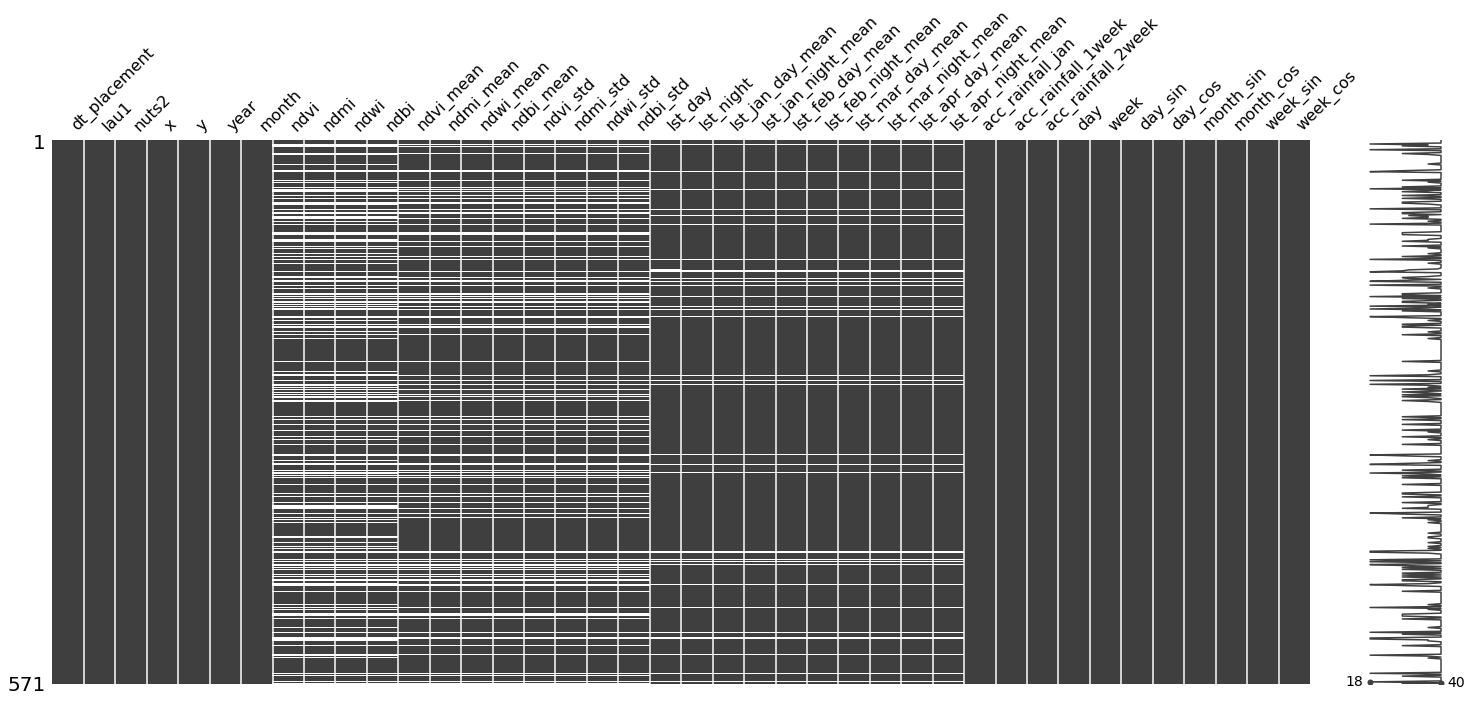

In [18]:
missingno.matrix(dataset)

In [19]:
mosquito_data = read_data(f'../../data/{NUTS0}_MSQ_culex_2010-2022_processed.csv')

Index(['nuts2', 'x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
       'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
       'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
       'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
       'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'wc_mean_dist_1000', 'coast_mean_dist_1000',
       'dem_mean_1km', 'slope_mean_1km', 'aspect_mean_1km', 'waw_mean_1km',
       'flow_accu_1km', 'mosq_now'],
      dtype='object')


In [20]:
mosquito_data.nuts2.unique()

array(['Veneto', 'Lombardia', 'Firuli-Venezia-Giulia',
       'Friuli-Venezia-Giulia'], dtype=object)

In [21]:
mosquito_data_nuts2 = mosquito_data.query("nuts2 == 'Veneto'").copy()
mosquito_data_nuts2.reset_index(inplace = True, drop = True)

In [22]:
mosq_columns = mosquito_data_nuts2.columns
mosq_columns

Index(['nuts2', 'x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
       'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
       'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
       'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
       'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'wc_mean_dist_1000', 'coast_mean_dist_1000',
       'dem_mean_1km', 'slope_mean_1km', 'aspect_mean_1km', 'waw_mean_1km',
       'flow_accu_1km', 'mosq_now'],
      dtype='object')

In [23]:
columns_to_keep = ['x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
                'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
                'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
                'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
                'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
                'acc_rainfall_jan', 'mosq_now']

mosquito_data_nuts2 = select_columns(mosquito_data_nuts2, columns_to_keep, columns_to_keep)

mosquito_data_nuts2 = reshape_dataset(mosquito_data_nuts2,['x','y','dt_placement'])

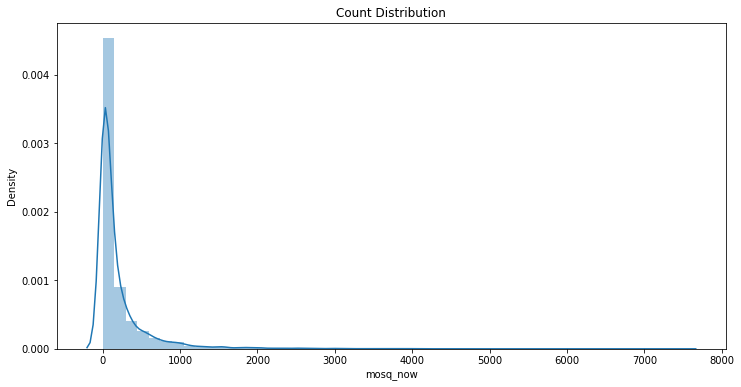

In [24]:
plt.figure(figsize=(12,6))
sns.distplot(mosquito_data_nuts2['mosq_now'])
plt.title('Count Distribution')
plt.show()

In [25]:
#quantile might change based on sns plots
mosq_quantilie = mosquito_data_nuts2['mosq_now'].quantile(0.90)

mosquito_data_nuts2['mosq_now'][mosquito_data_nuts2['mosq_now'] > mosq_quantilie] = mosq_quantilie+1

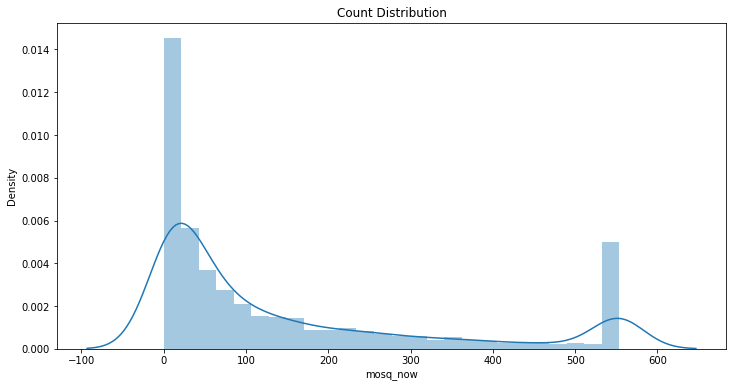

In [26]:
plt.figure(figsize=(12,6))
sns.distplot(mosquito_data_nuts2['mosq_now'])
plt.title('Count Distribution')
plt.show()

<AxesSubplot:>

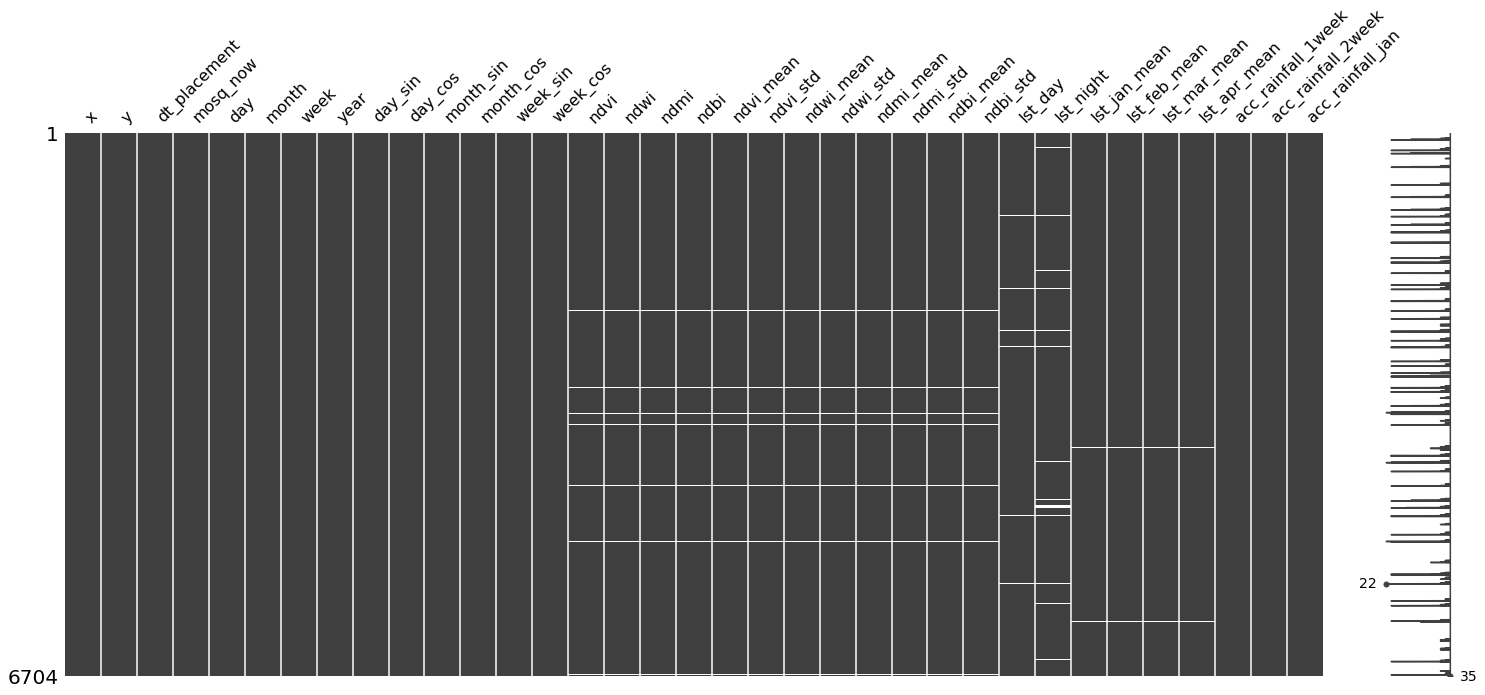

In [27]:
missingno.matrix(mosquito_data_nuts2)

In [28]:
imputer = KNNImputer()

features_for_impute = ['x', 'y', 'day', 'month', 'week', 'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                        'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean', 'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 
                        'lst_day', 'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan']

mosquito_data_sub = mosquito_data_nuts2[features_for_impute]

imputed_data = pd.DataFrame(imputer.fit_transform(mosquito_data_sub), columns = mosquito_data_sub.columns)

In [29]:
imputed_columns = ['ndvi','ndmi', 'ndwi', 'ndbi','ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean','ndvi_std', 'ndmi_std','ndwi_std','ndbi_std',
                   'lst_day','lst_night','lst_jan_mean','lst_feb_mean','lst_mar_mean','lst_apr_mean']

mosquito_data_nuts2[imputed_columns] = imputed_data[imputed_columns]

<AxesSubplot:>

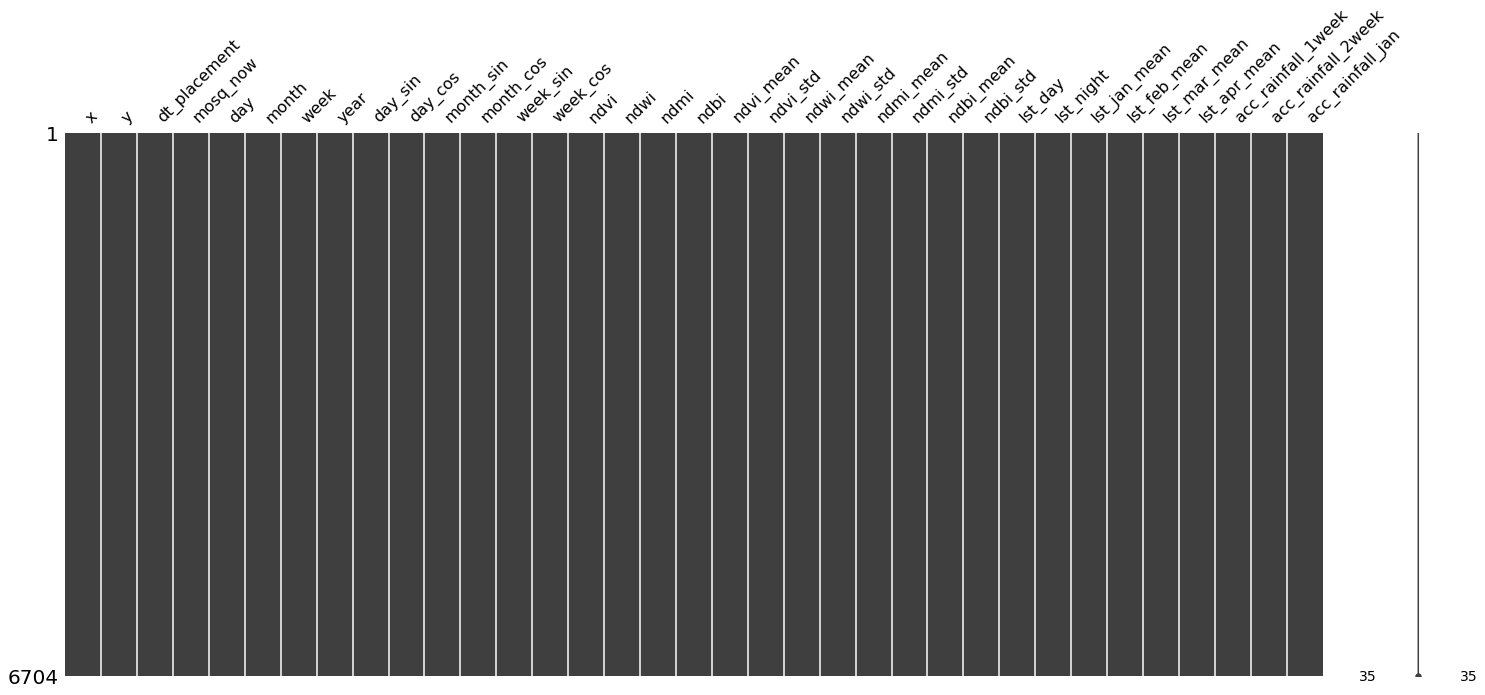

In [30]:
missingno.matrix(mosquito_data_nuts2)

In [31]:
step = 15
only_env = True
case_title = 'NN mosq regression'
exp = False
date_col = 'dt_placement'
model_type = 'mosquito_regression'
transform_target = True
augment = True

In [32]:
mosquito_data_nuts2 = initializer(mosquito_data_nuts2,2,10,25,step,[date_col], env=only_env, date_column = date_col, mosq_column='mosq_now')

Bounds: [  0.   61.  553.7]


In [33]:
train_X, train_y, test_X, test_y, scaler = transformations(mosquito_data_nuts2, model_type = model_type, split = 0.25, augment=augment)

training_set = Dataset(train_X, train_y, model_type=model_type, transform = transform_target)
testing_set = Dataset(test_X, test_y, model_type=model_type, transform = transform_target)

model = FeedforwardNeuralNetModel(num_features=len(train_X[0]), num_class=1, hidden_layers = [264,128,128,64], dropout=0.2, model_type=model_type, transform = transform_target)

Epoch 001: | Train Loss: 6.72596 | Val Loss: 6.05855 | Train Acc: 1.800| Val Acc: 1.597
Epoch 002: | Train Loss: 6.15673 | Val Loss: 4.22772 | Train Acc: 1.663| Val Acc: 1.210
Epoch 003: | Train Loss: 5.65868 | Val Loss: 4.02522 | Train Acc: 1.579| Val Acc: 1.142
Epoch 004: | Train Loss: 5.45217 | Val Loss: 4.15989 | Train Acc: 1.538| Val Acc: 1.161
Epoch 005: | Train Loss: 5.28389 | Val Loss: 4.01485 | Train Acc: 1.512| Val Acc: 1.132
Epoch 006: | Train Loss: 5.02279 | Val Loss: 4.19790 | Train Acc: 1.447| Val Acc: 1.147
Epoch 007: | Train Loss: 5.01504 | Val Loss: 4.25581 | Train Acc: 1.449| Val Acc: 1.155
Epoch 008: | Train Loss: 4.88396 | Val Loss: 4.15637 | Train Acc: 1.407| Val Acc: 1.127
Epoch 009: | Train Loss: 4.78606 | Val Loss: 4.08067 | Train Acc: 1.393| Val Acc: 1.126
Epoch 010: | Train Loss: 4.71472 | Val Loss: 4.16957 | Train Acc: 1.376| Val Acc: 1.133
Epoch 011: | Train Loss: 4.57634 | Val Loss: 4.01241 | Train Acc: 1.350| Val Acc: 1.105
Epoch 012: | Train Loss: 4.58238

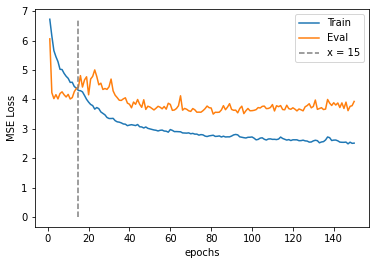

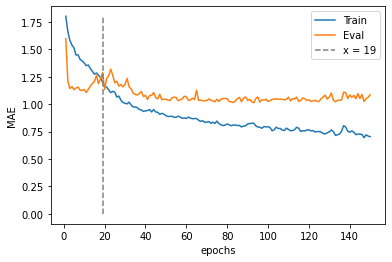

In [34]:
train, test, model = train_nn(model = model, learning_rate = 0.005, epochs = 150, batch_size = 128, train_set = training_set, test_set = testing_set, early_stop = False)

In [35]:
metrics(train, test, threshold=30)

MAE on train set:  85.13340127714928
min prediction: 1
max prediction: 921

MAE on test set:  97.22751628926082
Error ⩽ 30: 32.15 %
min prediction: 1
max prediction: 894


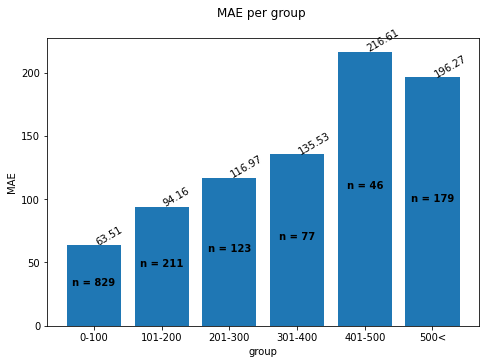

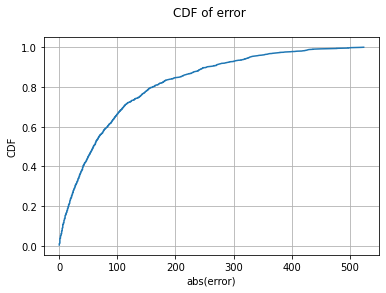

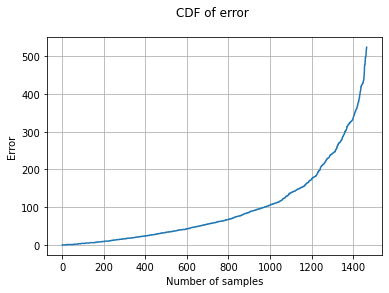

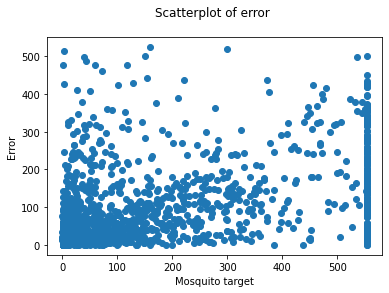

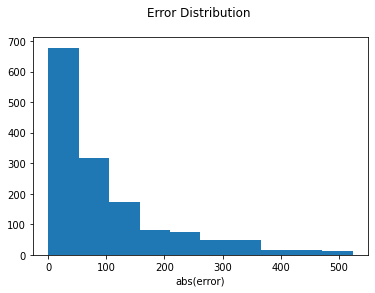

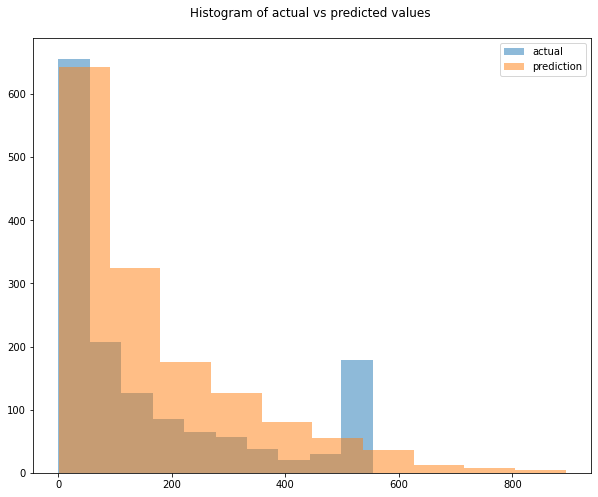

In [36]:
validation_plots(test,model_type)

Epoch 001: | Train Loss: 2.87526 | Val Loss: 1.01344 | Train Acc: 0.864| Val Acc: 1.394
Epoch 002: | Train Loss: 2.74785 | Val Loss: 0.60063 | Train Acc: 0.848| Val Acc: 0.394
Epoch 003: | Train Loss: 2.80343 | Val Loss: 0.04865 | Train Acc: 0.863| Val Acc: 0.394
Epoch 004: | Train Loss: 2.68438 | Val Loss: 0.12293 | Train Acc: 0.827| Val Acc: 0.394
Epoch 005: | Train Loss: 2.65253 | Val Loss: 0.08531 | Train Acc: 0.823| Val Acc: 0.394
Epoch 006: | Train Loss: 2.69302 | Val Loss: 0.54106 | Train Acc: 0.830| Val Acc: 0.394
Epoch 007: | Train Loss: 2.70336 | Val Loss: 0.93091 | Train Acc: 0.850| Val Acc: 1.394
Epoch 008: | Train Loss: 2.70299 | Val Loss: 1.08825 | Train Acc: 0.837| Val Acc: 1.394
Epoch 009: | Train Loss: 2.70447 | Val Loss: 0.63575 | Train Acc: 0.832| Val Acc: 0.394
Epoch 010: | Train Loss: 2.64637 | Val Loss: 0.26022 | Train Acc: 0.824| Val Acc: 0.394
Epoch 011: | Train Loss: 2.64141 | Val Loss: 0.96830 | Train Acc: 0.822| Val Acc: 1.394
Epoch 012: | Train Loss: 2.63574

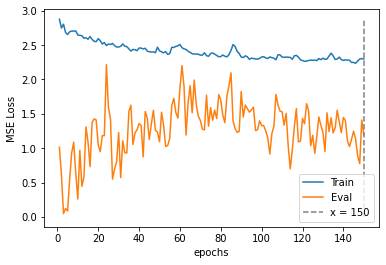

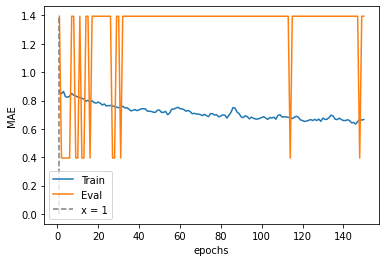

In [37]:
train_X, train_y, test_X, test_y, scaler = transformations(mosquito_data_nuts2, model_type = model_type, split = 0.000001, augment=augment)

training_set = Dataset(train_X, train_y, model_type=model_type, transform = transform_target)
testing_set = Dataset(test_X, test_y, model_type=model_type, transform = transform_target)

train, test, model = train_nn(model = model, learning_rate = 0.005, epochs = 150, batch_size = 128, train_set = training_set, test_set = testing_set, early_stop = False)

In [38]:
dataset_mamoth = dataset_mamoth_preparation(dataset, columns_to_keep)

In [39]:
mosqutio_predictions = dataset_mamoth[['x', 'y', 'dt_placement']].copy()

In [40]:
dataset_mamoth.drop(columns=['dt_placement'], inplace=True)

In [41]:
dataset_mamoth_sub = dataset_mamoth[features_for_impute]

In [42]:
mamoth_imputed = pd.DataFrame(imputer.transform(dataset_mamoth_sub), columns = dataset_mamoth_sub.columns)

In [43]:
dataset_mamoth[features_for_impute] = mamoth_imputed[features_for_impute]

<AxesSubplot:>

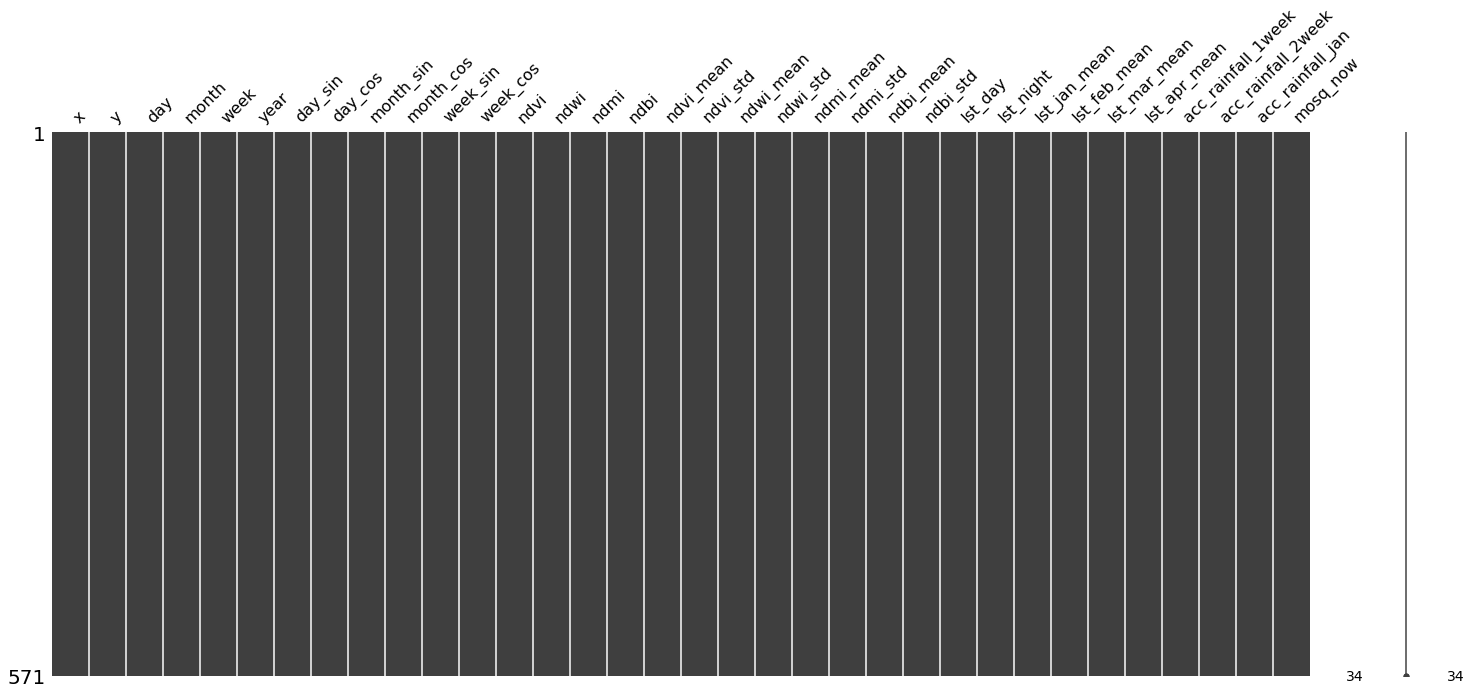

In [44]:
missingno.matrix(dataset_mamoth)

In [45]:
dataset_mamoth_X, dataset_mamoth_y = dataset_mamoth.iloc[:,:-1], dataset_mamoth.iloc[:,-1]

dataset_mamoth_X = scaler.transform(dataset_mamoth_X)

In [46]:
dataset_mamoth = Dataset(dataset_mamoth_X, dataset_mamoth_y, model_type=model_type, transform = transform_target)

In [47]:
predictions = give_predictions(model, dataset_mamoth)

In [48]:
mosqutio_predictions['mosq_pred'] = predictions

In [49]:
mosqutio_predictions

,x,y,dt_placement,mosq_pred
0,11.795390,45.357830,2023-05-01,128
1,12.049403,45.070483,2023-05-01,68
2,10.776730,45.556800,2023-05-01,72
3,11.965390,45.175310,2023-05-01,74
4,12.059120,46.313990,2023-05-01,16
...,...,...,...,...
566,11.127335,45.353970,2023-05-01,47
567,11.358050,45.347770,2023-05-01,135
568,12.178780,46.388350,2023-05-01,15
569,11.494300,45.437980,2023-05-01,81


In [50]:
mosqutio_predictions.to_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Culex_Predictions_2023-May-1st.csv', index = False)